# Vision-Language Models (VLMs) from Scratch: Basic Principles Explained

    Welcome! If you know some basic Python but have never touched a Vision-Language Model (VLM) before, you are in exactly the right place.

## 1. Introduction: What is a VLM?

Historically, AI models were hyper-specialized. You had "computer vision" models that could detect cars in a photo, and "natural language" models that could translate French to English. But they couldn't talk to each other. 

A **Vision-Language Model (VLM)** is like a perfectly bilingual translator who fluently speaks both "Image" and "Text". By understanding both modalities at the same time, VLMs can perform incredible feats:
* **Visual Question Answering (VQA):** "What color is the umbrella in this photo?"
* **Image Captioning:** Automatically writing "A golden retriever catching a frisbee."
* **Zero-Shot Classification:** Categorizing images into classes the model was never explicitly trained on, just by reading the class names!

**Why this is revolutionary:** We no longer need to train a new, custom AI for every specific visual task. We can just use text to "ask" the vision model what to do!

**Prerequisites for this notebook:**
* Basic Python & NumPy.
* That's it! We will explain the math and the machine learning concepts as we go.

## 2. Core Concepts – The Big Picture

How do we get an image of a dog and the word "dog" to mean the same thing to a computer? 

We use a concept called **Two Towers** and a **Shared Embedding Space**.

Imagine a massive, multidimensional room (the "Shared Embedding Space"). 
1. We send an image through a **Vision Encoder** (Tower 1). Its job is to look at the pixels and assign the image a specific set of coordinates in the room.
2. We send text through a **Text Encoder** (Tower 2). Its job is to look at the words and assign the text a specific set of coordinates in the *exact same room*.

If the model is well-trained, the coordinates for the image of a dog and the text "a photo of a dog" will be right next to each other!

```mermaid
flowchart LR
    I[🖼️ Image] --> VE(Vision Encoder)
    T[📝 Text] --> TE(Text Encoder)
    VE -->|Outputs Image Vector| Space((Shared Vector Space))
    TE -->|Outputs Text Vector| Space
    Space -.->|Matching concepts are pulled together| Space
```

    The "secret sauce" that makes this work is Contrastive Learning. It acts like a strict matchmaker: 
    it pulls matching image-text pairs closer together in the room, and pushes mismatched pairs far apart.

## 3. Math Made Easy: Embeddings and Similarity

When an encoder outputs "coordinates," we call that an **Embedding** or a **Vector**. It's just a list of numbers. 

To figure out if an image vector and a text vector are pointing to the same concept, we measure the angle between them. This is called **Cosine Similarity**.

### The Math
If we have an image vector $I$ and a text vector $T$, the cosine similarity $S_c(I,T)$ is calculated as:

$$S_c(I,T) = \frac{I \cdot T}{\|I\| \|T\|}$$

* $I \cdot T$ (The dot product): Multiply the matching numbers in the lists together and add them up. If they point in the same direction, this number gets big.
* $\|I\| \|T\|$ (The magnitudes): This just scales the result so the final score is always between **-1** (exact opposites) and **1** (perfect match). A score of **0** means they are completely unrelated.

Let's visualize this with some code!

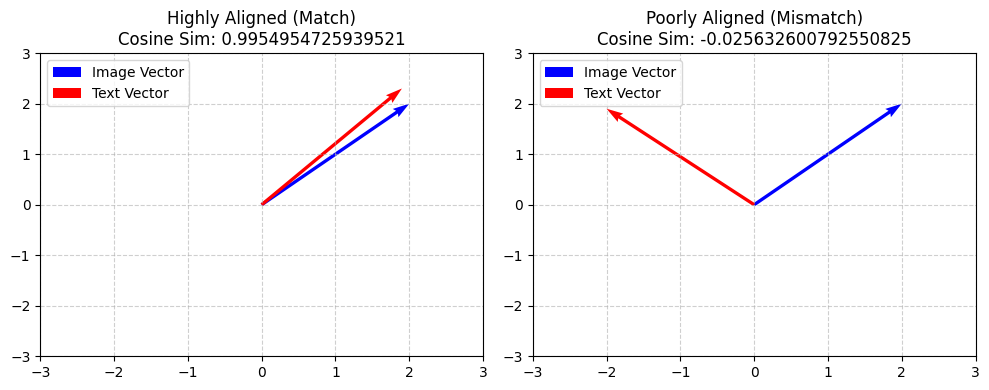

In [1]:
# Run this cell to visualize Cosine Similarity!
import numpy as np
import matplotlib.pyplot as plt

def plot_vectors(v1, v2, title, ax):
    ax.quiver(0, 0, v1[0], v1[1], angles='xy', scale_units='xy', scale=1, color='blue', label='Image Vector')
    ax.quiver(0, 0, v2[0], v2[1], angles='xy', scale_units='xy', scale=1, color='red', label='Text Vector')
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.grid(True, linestyle='--', alpha=0.6)
    
    # Calculate cosine similarity
    dot_product = np.dot(v1, v2)
    norm_v1 = np.linalg.norm(v1)
    norm_v2 = np.linalg.norm(v2)
    cos_sim = dot_product / (norm_v1 * norm_v2)
    
    ax.set_title(f"{title}\nCosine Sim: {cos_sim}")
    ax.legend(loc='upper left')

# Create our plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Scenario 1: Highly aligned (A dog image and "a photo of a dog")
img_vec_1 = np.array([2, 2])
text_vec_1 = np.array([1.9, 2.3])
plot_vectors(img_vec_1, text_vec_1, "Highly Aligned (Match)", ax1)

# Scenario 2: Poorly aligned (A dog image and "a photo of a car")
img_vec_2 = np.array([2, 2])
text_vec_2 = np.array([-2, 1.9])
plot_vectors(img_vec_2, text_vec_2, "Poorly Aligned (Mismatch)", ax2)

plt.tight_layout()
plt.show()

# What you should see:
# Two graphs. The left graph shows arrows pointing almost the same way (Similarity ~ 1.0).
# The right graph shows arrows pointing apart (Similarity is much lower).

### Try it yourself!
Change the numbers in the cell below to see how cosine similarity changes. Try to make a cosine similarity of exactly `0.0` (Hint: make the vectors perpendicular, like `[0, 2]` and `[2, 0]`).

In [2]:
# Try it yourself: change these lists of two numbers!
my_image_vector = np.array([1.0, 1.0])
my_text_vector = np.array([1.0, 1.0])

cos_sim = np.dot(my_image_vector, my_text_vector) / (np.linalg.norm(my_image_vector) * np.linalg.norm(my_text_vector))
print(f"Your Cosine Similarity is: {cos_sim:.4f}")

Your Cosine Similarity is: 1.0000


## 4. Hands-on Demo: CLIP (The Classic VLM)

OpenAI's **CLIP** (Contrastive Language-Image Pretraining) is the model that popularized this entire approach. Let's load it up and play with it!

First, we need to install the tools.

In [3]:
# Install the necessary libraries
!pip install -q torch torchvision transformers matplotlib scikit-learn requests Pillow
print("Libraries installed successfully!")

Libraries installed successfully!


In [33]:
# Import libraries and load the CLIP model from Hugging Face
import torch
import requests
from PIL import Image
from transformers import CLIPProcessor, CLIPModel
import matplotlib.pyplot as plt

print("Downloading and loading the CLIP model... (this might take a minute)")
# We are using a small version of CLIP (ViT-B/32) so it runs fast!
model_id = "openai/clip-vit-large-patch14-336"
model = CLIPModel.from_pretrained(model_id)
processor = CLIPProcessor.from_pretrained(model_id)
print("Model loaded!")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14-336
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Model loaded!


### Demo 1: Compute Image-Text Similarity Scores
Let's feed CLIP an image of a cat ,a dog and three different text descriptions to see which one it thinks is the best match.

In [34]:
def CLIP_demo(url, texts):
    """
    This function shows how CLIP (an AI model) looks at a picture from the internet 
    and decides which of your text descriptions best matches it.
    
    It's like asking the AI: "Which sentence describes this image the best?"
    """
    
    # Step 0: Trick the website so it doesn't block us (some sites hate bots)
    # We pretend to be a normal web browser
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/114.0.0.0 Safari/537.36"
    }
    
    # 1. Download the image from the internet link (url) you gave
    print("Downloading the image...")
    response = requests.get(url, headers=headers, stream=True)
    response.raise_for_status()   # If something goes wrong while downloading, stop and show error
    
    # Open the downloaded image and make it smaller (300x300) so it's faster to process
    image = Image.open(response.raw).resize((300, 300))
    
    # 2. Show the list of text descriptions you want to compare with the image
    print("Your text descriptions are:")
    print(texts)
    
    # 3. Prepare the image and texts in a special format that the CLIP AI model understands
    # (Just like translating human language into "AI language")
    inputs = processor(text=texts, images=image, return_tensors="pt", padding=True)
    
    # 4. Ask the CLIP model to look at the image and texts and give its opinion
    # We use "no_grad" because we are not teaching the model, just asking it a question
    with torch.no_grad():
        outputs = model(**inputs)
    
    # 5. Get the similarity scores (how well each text matches the image)
    # Turn those scores into nice percentages that add up to 100%
    logits_per_image = outputs.logits_per_image
    probs = logits_per_image.softmax(dim=1).numpy()[0]
    
    # 6. Show the results in a beautiful picture
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Left side: Show the original image
    ax1.imshow(image)
    ax1.axis('off')
    ax1.set_title("The Picture We Downloaded")
    
    # Right side: Show a bar chart of how confident CLIP is about each text
    ax2.barh(texts, probs, color=['green', 'red', 'red'])  # Green = most likely match
    ax2.set_xlim(0, 1)
    ax2.set_title("CLIP's Guess (Probability)")
    ax2.set_xlabel("How likely is this description? (0 to 1)")
    
    plt.tight_layout()
    plt.show()
    
    # Bonus: Print the probabilities nicely for easy reading
    print("\nCLIP thinks the probabilities are:")
    for text, prob in zip(texts, probs):
        print(f"{text:40} → {prob*100:6.2f}%")

🚀 Starting CLIP Demo - Testing Cat and Dog!
We will test the same 3 descriptions on TWO different pictures

🐱 Testing the CAT image...
Your text descriptions are:
['a photo of a cat', 'a photo of a dog', 'a delicious cheeseburger']


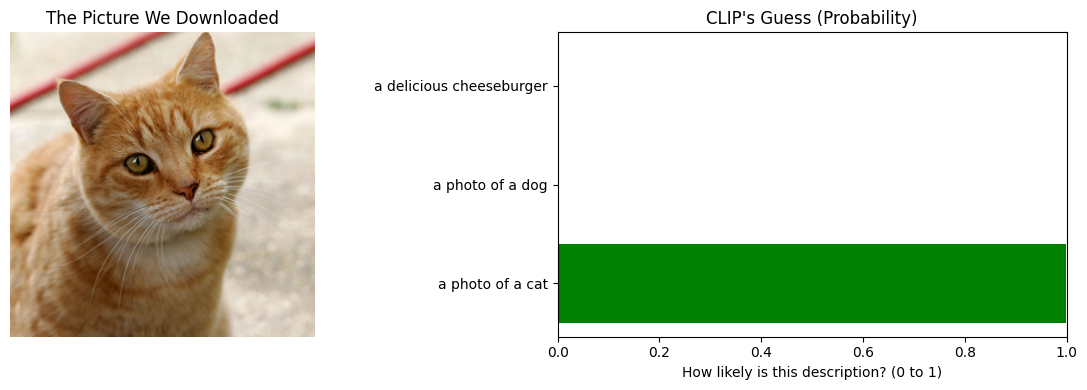


CLIP thinks the probabilities are:
a photo of a cat                         →  99.89%
a photo of a dog                         →   0.09%
a delicious cheeseburger                 →   0.02%

🐶 Testing the DOG image...
Your text descriptions are:
['a photo of a cat', 'a photo of a dog', 'a delicious cheeseburger']


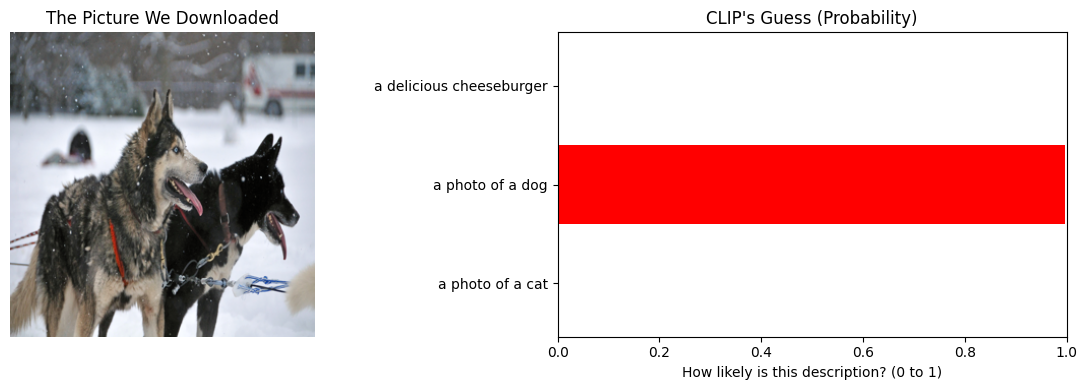


CLIP thinks the probabilities are:
a photo of a cat                         →   0.22%
a photo of a dog                         →  99.77%
a delicious cheeseburger                 →   0.01%

✅ Done! 
Compare the two graphs:
   • The CAT image should give high score to 'a photo of a cat'
   • The DOG image should give high score to 'a photo of a dog'
   • Both should give very low score to 'cheeseburger' 😄


In [35]:
# ================================================
# SUPER SIMPLE CLIP DEMO - Testing Cat vs Dog
# Perfect for Complete Beginners! 😊
# ================================================

# Step 1: Image links
url_cat = "https://upload.wikimedia.org/wikipedia/commons/thumb/3/3a/Cat03.jpg/1200px-Cat03.jpg"
url_dog = "https://upload.wikimedia.org/wikipedia/commons/7/7a/Huskiesatrest.jpg"

# Step 2: List of possible descriptions
# CLIP will check which sentence best matches the picture
texts = [
    "a photo of a cat",          # Should match the cat image well
    "a photo of a dog",          # Should match the dog image well
    "a delicious cheeseburger"   # Should match neither
]

# Step 3: Run the demo for both images
print("🚀 Starting CLIP Demo - Testing Cat and Dog!")
print("=" * 70)
print("We will test the same 3 descriptions on TWO different pictures")
print("=" * 70)

print("\n🐱 Testing the CAT image...")
CLIP_demo(url_cat, texts)

print("\n🐶 Testing the DOG image...")
CLIP_demo(url_dog, texts)

print("\n" + "=" * 70)
print("✅ Done! ")
print("Compare the two graphs:")
print("   • The CAT image should give high score to 'a photo of a cat'")
print("   • The DOG image should give high score to 'a photo of a dog'")
print("   • Both should give very low score to 'cheeseburger' 😄")

### Try it yourself!
Find an image URL on Google, paste it below, and write your own text descriptions to see if you can trick CLIP.

In [ ]:
# 1. Fetch an image from the internet
url = "PASTE_IMAGE_URL_HERE"
# 2. Define our candidate text descriptions
texts = ["description 1", "description 2", "description 3"]
CLIP_demo(url_cat, texts)

### Demo 2: Pretraining‑Free Image Classification

Traditional models needed thousands of labeled images to learn a new class (like "airplane"). 

With CLIP, we just give it an image and a list of classes formatted as sentences (`"a photo of a {class}"`). Whichever sentence has the highest similarity score becomes our prediction!

In [36]:
import numpy as np
# Step 1: Choose the image you want to test
# This is a picture of an airplane
url = "https://www.raf.mod.uk/sites/raf-beta/cache/file/3D3D6E48-2A42-4BC3-AEA83180035B008D_600x300.jpg"

# Step 2: Download the image from the internet
# We add a "User-Agent" so websites don't think we are a robot and block us
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/114.0.0.0 Safari/537.36"
}

print("📥 Downloading the image...")
response = requests.get(url, headers=headers, stream=True)
response.raise_for_status()   # Stop if download fails

# Open the image and make it smaller (faster to process)
plane_image = Image.open(response.raw).resize((300, 300))

# Step 3: Create a list of things we want CLIP to check
classes = ["car", "bird", "dog", "airplane", "boat"]

# PRO TIP for Beginners:
# CLIP works much better when we write full sentences instead of single words.
# So we turn "airplane" into "a photo of an airplane"
prompts = [f"a photo of a {c}" for c in classes]

print("Testing these descriptions:")
for p in prompts:
    print(f"   • {p}")

# Step 4: Prepare the data and ask CLIP for its opinion
inputs = processor(text=prompts, images=plane_image, return_tensors="pt", padding=True)

# Get the model's predictions (no training, just asking)
outputs = model(**inputs)

# Convert the scores into easy-to-understand percentages
probs = outputs.logits_per_image.softmax(dim=1).detach().numpy()[0]

# Step 5: Show the result in a nice way
best_idx = np.argmax(probs)        # Find which one has the highest score
best_class = classes[best_idx]
best_prob = probs[best_idx] * 100

print("\n" + "="*60)
print(f"🎯 CLIP's Prediction:")
print(f"   This picture is most likely a **{best_class.upper()}**")
print(f"   Confidence: {best_prob:.1f}%")
print("="*60)

# Bonus: Show all probabilities so you can see everything clearly
print("\nAll possibilities:")
for i, (prompt, prob) in enumerate(zip(prompts, probs)):
    check = "✅" if i == best_idx else "  "
    print(f"{check} {prompt:25} → {prob*100:6.1f}%")

📥 Downloading the image...
Testing these descriptions:
   • a photo of a car
   • a photo of a bird
   • a photo of a dog
   • a photo of a airplane
   • a photo of a boat

🎯 CLIP's Prediction:
   This picture is most likely a **AIRPLANE**
   Confidence: 96.4%

All possibilities:
   a photo of a car          →    1.4%
   a photo of a bird         →    1.3%
   a photo of a dog          →    0.7%
✅ a photo of a airplane     →   96.4%
   a photo of a boat         →    0.2%


### Demo 3: Visualizing the Shared Embedding Space (PCA)

We talked about the "Shared Room" where text and images live. In reality, this room has 512 dimensions (way too many for our puny human brains to see). 

We can use a math trick called **PCA** (Principal Component Analysis) to squash those 512 dimensions down to just 2 dimensions so we can draw it on a flat graph. Let's see if matching texts and images actually sit close to each other!

In [37]:
"""
Image Downloader Script
=======================

This script downloads images from various URLs (including Wikimedia), 
resizes them to 300x300 pixels, and stores them as PIL Image objects in a list.
"""

import requests
from PIL import Image


# =============================================================================
# CONFIGURATION
# =============================================================================

# Use a realistic browser User-Agent to prevent 403 Forbidden errors from sites
# like Wikimedia that block default Python requests.
HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/114.0.0.0 Safari/537.36"
    )
}

# List of image URLs to download
# Each URL is followed by a comment describing what the image is (for clarity)
IMAGE_URLS = [
    # Plane - Spitfire plane photo from Wikimedia
    "https://upload.wikimedia.org/wikipedia/commons/thumb/5/55/Spitfire_-_Season_Premiere_Airshow_2018_%28cropped%29.jpg/1280px-Spitfire_-_Season_Premiere_Airshow_2018_%28cropped%29.jpg",
    
    # Cat (orange) - from alleycat.org
    "https://www.alleycat.org/wp-content/uploads/2019/03/FELV-cat.jpg",
    
    # The Beatles - Abbey Road album cover
    "https://lift3cdn.nl/image/115/1596x898/nieuws---platenhoes-abbey-road---beatles.jpg",
    
    # Military Tank - Challenger 2 in Iraq
    "https://upload.wikimedia.org/wikipedia/commons/3/30/Challenger_2_Main_Battle_Tank_patrolling_outside_Basra%2C_Iraq_MOD_45148325.jpg",

    # Monkey - Panchi-kun  in Ichikawa City Zoo
    "https://upload.wikimedia.org/wikipedia/commons/thumb/d/d7/Punch_the_Monkey_Ichikawa_City_Zoo_2026_9.png/1280px-Punch_the_Monkey_Ichikawa_City_Zoo_2026_9.png"
]


# =============================================================================
# MAIN PROCESSING
# =============================================================================

def download_and_resize_images(urls: list[str], target_size: tuple[int, int] = (300, 300)) -> list[Image.Image]:
    """
    Downloads images from the given URLs, resizes them, and returns a list of PIL Image objects.
    
    Args:
        urls (list[str]): List of image URLs to download.
        target_size (tuple[int, int]): Desired width and height for resizing (default: 300x300).
    
    Returns:
        list[Image.Image]: List of resized PIL Image objects.
    
    Raises:
        requests.exceptions.HTTPError: If any download fails (e.g., 404, 403).
    """
    images = []
    
    print("Downloading and resizing images...\n")
    
    for i, url in enumerate(urls, start=1):
        try:
            print(f"[{i}/{len(urls)}] Downloading: {url[:80]}{'...' if len(url) > 80 else ''}")
            
            # Download the image with streaming to handle large files efficiently
            response = requests.get(url, headers=HEADERS, stream=True, timeout=10)
            response.raise_for_status()   # Raises HTTPError for bad responses (4xx, 5xx)
            
            # Open the image directly from the response stream
            img = Image.open(response.raw)
            
            # Resize the image while preserving aspect ratio? 
            # Note: .resize() does NOT preserve aspect ratio by default.
            # If you want to keep aspect ratio, consider using Image.thumbnail() instead.
            img_resized = img.resize(target_size)
            
            images.append(img_resized)
            print(f"    ✓ Success - Original size: {img.size} → Resized to: {img_resized.size}")
            
        except requests.exceptions.RequestException as e:
            print(f"    ✗ Failed to download: {e}")
        except Exception as e:
            print(f"    ✗ Error processing image: {e}")
    
    print(f"\nDownload complete! Total images loaded: {len(images)}")
    return images



# Download all images and store them in a list
images = download_and_resize_images(IMAGE_URLS)
    
# Print summary
print("\n" + "="*60)
print("Final Result:")
print(f"Type of 'images': {type(images)}")
print(f"Number of images: {len(images)}")
    
if images:
    print(f"First image size: {images[0].size}")
    print(f"Image mode: {images[0].mode}")
    


[1/5] Downloading: https://upload.wikimedia.org/wikipedia/commons/thumb/5/55/Spitfire_-_Season_Prem...
    ✓ Success - Original size: (1280, 930) → Resized to: (300, 300)
[2/5] Downloading: https://www.alleycat.org/wp-content/uploads/2019/03/FELV-cat.jpg
    ✓ Success - Original size: (703, 463) → Resized to: (300, 300)
[3/5] Downloading: https://lift3cdn.nl/image/115/1596x898/nieuws---platenhoes-abbey-road---beatles....
    ✓ Success - Original size: (1596, 898) → Resized to: (300, 300)
[4/5] Downloading: https://upload.wikimedia.org/wikipedia/commons/3/30/Challenger_2_Main_Battle_Tan...
    ✓ Success - Original size: (4064, 2704) → Resized to: (300, 300)
[5/5] Downloading: https://upload.wikimedia.org/wikipedia/commons/thumb/d/d7/Punch_the_Monkey_Ichik...
    ✓ Success - Original size: (1280, 1280) → Resized to: (300, 300)

Download complete! Total images loaded: 5

Final Result:
Type of 'images': <class 'list'>
Number of images: 5
First image size: (300, 300)
Image mode: RGB


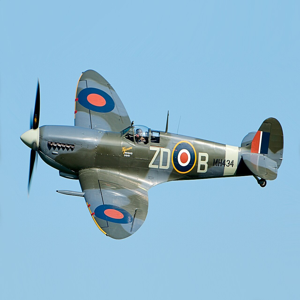

In [38]:
images[0]

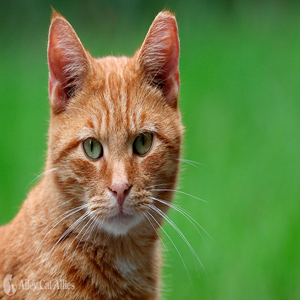

In [39]:
images[1]

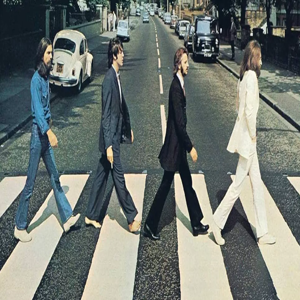

In [40]:
images[2]

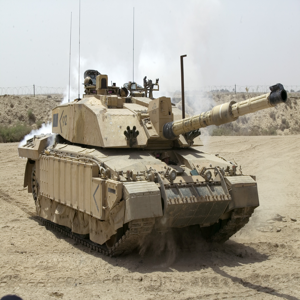

In [41]:
images[3]

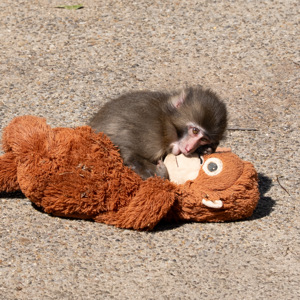

In [42]:
images[4]

In [48]:
"""
Image and Text Feature Extraction using CLIP
============================================

This script takes images and text descriptions, and extracts their features 
using a CLIP model. Features are then converted to numpy arrays for easy use.
"""

import torch
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------------------------
# Sample Data
# ------------------------------------------------------------------------------

# Text descriptions that match the images we downloaded earlier
texts = [
    "The Supermarine Spitfire aircraft",      # matches first image (plane)
    "Orange tabby cat",                # matches second image (cat)
    "The Beatles Abbey Road album picture",                   # matches third image (Abbey Road)
    "Challenger 2 main battle tank",  # matches fourth image (tank)
    "A monkey hugging a doll"                        # matches fifty image (Monkey)
]

# ------------------------------------------------------------------------------
# Prepare Inputs for the Model
# ------------------------------------------------------------------------------

# Convert images and texts into the format the model expects
image_inputs = processor(
    images=images, 
    return_tensors="pt", 
    padding=True
)

text_inputs = processor(
    text=texts, 
    return_tensors="pt", 
    padding=True
)

# ------------------------------------------------------------------------------
# Extract Features using CLIP Model
# ------------------------------------------------------------------------------

# Disable gradient calculation (we are only doing inference, not training)
with torch.no_grad():
    # Get feature vectors for images
    image_features = model.get_image_features(**image_inputs)
    
    # Get feature vectors for texts
    text_features = model.get_text_features(**text_inputs)

# ------------------------------------------------------------------------------
# Convert Features to NumPy Arrays
# ------------------------------------------------------------------------------

# Move features from GPU to CPU and convert to numpy
np_image_features = image_features.pooler_output.detach().cpu().numpy()
np_text_features = text_features.pooler_output.detach().cpu().numpy()

# ------------------------------------------------------------------------------
# Display Results
# ------------------------------------------------------------------------------

print("Image Features Shape:", np_image_features.shape)
print("Text Features Shape: ", np_text_features.shape)
print("\n" + "="*60)

print("Image Features:")
print(np_image_features)
print("\n" + "-"*60)

print("Text Features:")
print(np_text_features)
# Convert images and texts into the format the model expects

Image Features Shape: (5, 768)
Text Features Shape:  (5, 768)

Image Features:
[[-0.37821352  0.07502925  0.82701445 ...  0.8036483  -0.4801911
  -0.2374531 ]
 [-0.27936777  1.1240594   0.40626165 ...  0.12334207  0.45687637
   0.5423641 ]
 [ 0.10453355  1.496767    0.64190924 ... -0.17589316  0.4245751
   0.8312311 ]
 [ 0.12098774 -0.9096364  -0.29567727 ...  0.3885206  -0.16388188
  -0.48946458]
 [-1.0969973   0.249996   -0.74489063 ... -0.22543417 -0.21001562
   0.60924065]]

------------------------------------------------------------
Text Features:
[[ 0.33061898 -0.24180825  0.42323563 ...  0.01459505  0.36307278
  -0.28115708]
 [ 0.19506435  0.7811185   0.26786286 ... -0.93671787  0.1234913
   0.08973003]
 [-0.21098462  0.97208625  0.12427992 ... -0.09085932  0.33379704
   0.21244489]
 [-0.13097434 -0.1999011  -0.45472136 ... -0.34888303  0.13248195
  -0.72496843]
 [ 0.25695756 -0.14496483  0.16505936 ...  0.08837584  0.09837213
   0.18498877]]


In [49]:
"""
PCA - Reduce Features to 2D for Visualization
=============================================

This script takes the image and text features extracted from CLIP,
combines them, scales them properly, and reduces them to 2 dimensions
using PCA so we can easily plot or visualize them.
"""

import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------------------------
# Combine Image and Text Features
# ------------------------------------------------------------------------------

# Stack image features and text features vertically into one array
# Shape will be (8, feature_dimension) → 4 images + 4 texts
all_features = np.vstack((np_image_features, np_text_features))

print("Combined features shape before PCA:", all_features.shape)

# ------------------------------------------------------------------------------
# Scale the Features (Very Important before PCA)
# ------------------------------------------------------------------------------

# StandardScaler removes the mean and scales to unit variance.
# This is highly recommended before applying PCA.
all_features_scaled = StandardScaler().fit_transform(all_features)

# Optional: You can also use MinMaxScaler if you prefer values between 0 and 1
# all_features_scaled = pre.MinMaxScaler().fit_transform(all_features)

# ------------------------------------------------------------------------------
# Apply PCA to Reduce to 2 Dimensions
# ------------------------------------------------------------------------------

# Create PCA object that will keep only the top 2 principal components
pca = PCA(n_components=2)

# Fit PCA on the scaled features and transform them to 2D
features_2d = pca.fit_transform(all_features_scaled)

# ------------------------------------------------------------------------------
# (Optional) Scale the 2D output again
# ------------------------------------------------------------------------------

# Sometimes people scale the final 2D points for better visualization.
# Uncomment the line below only if needed.
# features_2d = StandardScaler().fit_transform(features_2d)

# ------------------------------------------------------------------------------
# Final Result
# ------------------------------------------------------------------------------

print("Final 2D features shape:", features_2d.shape)
print("\n2D Features (PCA):")
print(features_2d)

# Optional: Print explained variance to see how much information is preserved
print("\nExplained variance ratio:", pca.explained_variance_ratio_)
print("Total variance explained: {:.2%}".format(sum(pca.explained_variance_ratio_)))

Combined features shape before PCA: (10, 768)
Final 2D features shape: (10, 2)

2D Features (PCA):
[[ 15.853731    -1.9591813 ]
 [ -9.1551285  -14.889765  ]
 [  5.537405    24.496555  ]
 [ 17.903984   -11.66155   ]
 [-17.942822     0.18300688]
 [  5.820341    -0.93441147]
 [ -7.4324856   -7.392221  ]
 [ -2.9998243   14.429038  ]
 [  6.8764925   -3.1821625 ]
 [-14.461702     0.9106935 ]]

Explained variance ratio: [0.17745592 0.16097921]
Total variance explained: 33.84%


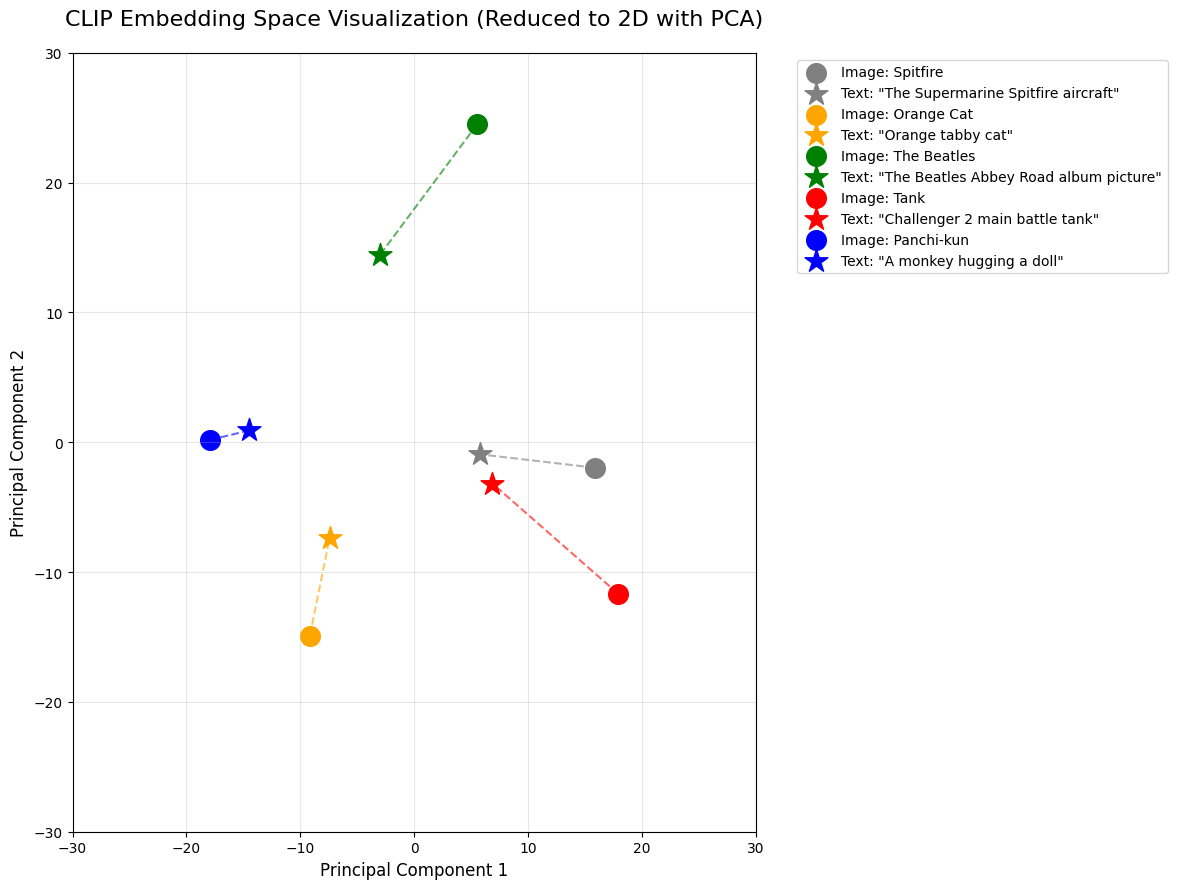

In [50]:
"""
Visualize Image and Text Features in 2D
=======================================

This script creates a clear scatter plot showing how CLIP embeds 
images and their matching text descriptions in the same space.
Each pair is connected by a dashed line.
"""

import matplotlib.pyplot as plt

# ------------------------------------------------------------------------------
# Split the 2D features back into images and texts
# ------------------------------------------------------------------------------

# First 4 rows = image features, next 4 rows = text features
img_2d = features_2d[:5]
txt_2d = features_2d[5:]

# ------------------------------------------------------------------------------
# Plot Setup
# ------------------------------------------------------------------------------

plt.figure(figsize=(12, 9))

# Set reasonable axis limits (you can adjust these later if needed)
plt.xlim(-30, 30)
plt.ylim(-30, 30)

# Colors and labels for the 4 items
colors = ['gray', 'orange', 'green', 'red',"blue"]
labels = ['Spitfire', 'Orange Cat', 'The Beatles', 'Tank',"Panchi-kun"]

# ------------------------------------------------------------------------------
# Plot each image-text pair
# ------------------------------------------------------------------------------

for i in range(5):
    # Plot Image as a large circle
    plt.scatter(
        img_2d[i, 0], 
        img_2d[i, 1], 
        color=colors[i], 
        marker='o', 
        s=200, 
        label=f'Image: {labels[i]}'
    )
    
    # Plot Text as a large star
    plt.scatter(
        txt_2d[i, 0], 
        txt_2d[i, 1], 
        color=colors[i], 
        marker='*', 
        s=300, 
        label=f'Text: "{texts[i]}"'
    )
    
    # Draw a dashed line connecting the image and text
    plt.plot(
        [img_2d[i, 0], txt_2d[i, 0]], 
        [img_2d[i, 1], txt_2d[i, 1]], 
        color=colors[i], 
        linestyle='--', 
        alpha=0.6,
        linewidth=1.5
    )

# ------------------------------------------------------------------------------
# Add titles, labels, and legend
# ------------------------------------------------------------------------------

plt.title("CLIP Embedding Space Visualization (Reduced to 2D with PCA)", 
          fontsize=16, pad=20)

plt.xlabel("Principal Component 1", fontsize=12)
plt.ylabel("Principal Component 2", fontsize=12)

plt.grid(True, alpha=0.3)

# Place legend outside the plot to avoid overlapping points
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

While the PCA scatter plot shows us the overall clustering of the data points in reduced dimensions, we also generated a correlation heat map for a more detailed view of pairwise relationships.
The diagonal of the heat map displays better self-correlation and is coloured bright yellow. Cells representing strong positive correlations between variables are shown in shades of yellow, whereas weaker correlations or negative correlations appear in shades of blue. This colour gradient makes it visually intuitive to identify which variables are highly related and which are relatively independentWhile the PCA scatter plot shows us the overall clustering of the data points in reduced dimensions, we also generated a correlation heat map for a more detailed view of pairwise relationships.

The diagonal of the heat map displays perfect self-correlation (value = 1) and is coloured bright yellow. Cells representing strong positive correlations between variables are shown in shades of yellow, whereas weaker correlations or negative correlations appear in shades of blue. This colour gradient makes it visually intuitive to identify which variables are highly related and which are relatively independent..

Cosine similarity matrix:
[[0.27271104 0.09342644 0.08235278 0.12002861 0.02870684]
 [0.08435797 0.2833857  0.12252859 0.0831012  0.04605635]
 [0.06307936 0.09649373 0.2759763  0.0919745  0.05243137]
 [0.08900298 0.12039792 0.07294548 0.27639085 0.00767414]
 [0.03719141 0.10384769 0.13723509 0.05125657 0.31266302]]
Shape: (5, 5)


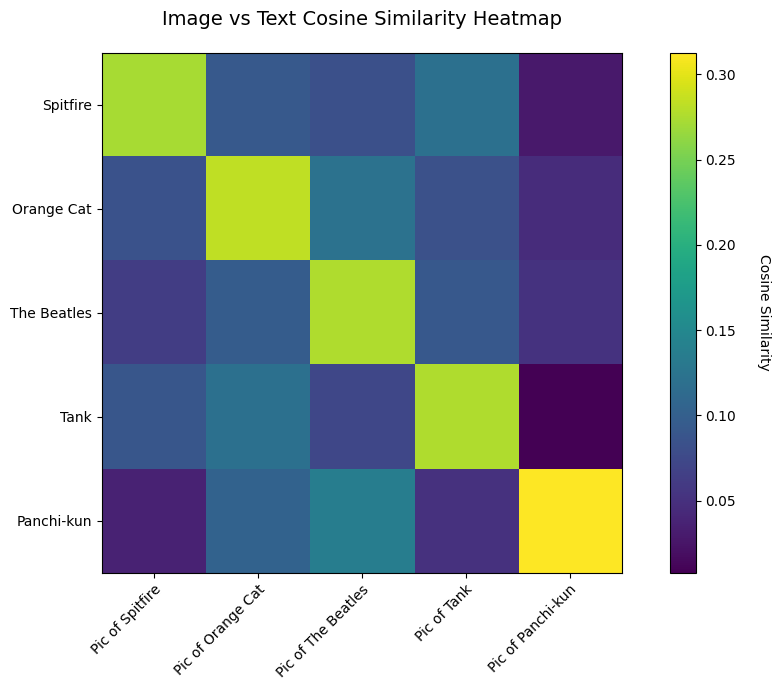

In [51]:
import matplotlib.pyplot as plt
import numpy as np

# ================================================================
# STEP 1: Calculate Cosine Similarities using Nested Loops
# ================================================================
# We will compute cosine similarity between every image and every text feature
# Cosine similarity = (dot product) / (norm of image * norm of text)

cos_sims_list = []

# Loop through each image feature
for v_img in np_image_features:
    
    cos_sim_i = []   # Store similarities of this image with all texts
    
    # Loop through each text feature
    for v_text in np_text_features:
        
        # Calculate cosine similarity for this image-text pair
        dot_product = np.dot(v_img, v_text)
        norm_img = np.linalg.norm(v_img)
        norm_text = np.linalg.norm(v_text)
        
        cos_sim_ik = dot_product / (norm_img * norm_text)
        
        cos_sim_i.append(cos_sim_ik)
    
    # Add this image's similarities to the main list
    cos_sims_list.append(cos_sim_i)

# Convert the list of lists into a clean NumPy array
cos_sims = np.array(cos_sims_list)

print("Cosine similarity matrix:")
print(cos_sims)
print("Shape:", cos_sims.shape)

# ================================================================
# STEP 2: Prepare Labels for the Heatmap
# ================================================================
# These labels will be shown on the rows and columns of the heatmap

row_labels = ['Spitfire', 'Orange Cat', 'The Beatles', 'Tank', 'Panchi-kun']      # Rows = Images
col_labels = ['Pic of Spitfire', 'Pic of Orange Cat', 'Pic of The Beatles',
              'Pic of Tank', 'Pic of Panchi-kun']                                 # Columns = Text descriptions

data = cos_sims   # The similarity matrix we calculated

# ================================================================
# STEP 3: Create and Customize the Heatmap
# ================================================================
# Create the figure and axis
fig, ax = plt.subplots(figsize=(10, 7))   # Bigger size for better readability

# Draw the heatmap
im = ax.imshow(data, cmap="viridis")      # viridis is a clear and beautiful colormap

# Add color bar to show what the colors mean
cbar = ax.figure.colorbar(im, ax=ax)
cbar.ax.set_ylabel("Cosine Similarity", rotation=-90, va="bottom", labelpad=15)

# Set the tick positions and labels
ax.set_xticks(np.arange(len(col_labels)))
ax.set_yticks(np.arange(len(row_labels)))

ax.set_xticklabels(col_labels)
ax.set_yticklabels(row_labels)

# Rotate x-axis labels so they don't overlap
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# Add title and axis labels
ax.set_title("Image vs Text Cosine Similarity Heatmap", fontsize=14, pad=20)


# Adjust layout to prevent labels from being cut off
fig.tight_layout()

# Show the final heatmap
plt.show()